In [1]:
from matplotlib import pyplot
import numpy as np
import numpy
import scipy.io.wavfile

import pyaudio
import bob.ap

from __future__ import division

%run -i lib/audio.py

28038.3352328


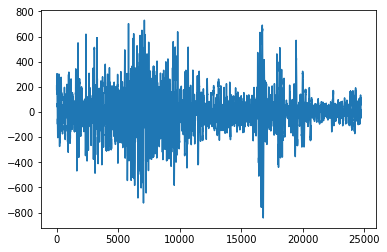

In [44]:
d = data[7000:]
print((d.astype(np.float) ** 2).mean())
pyplot.plot(d)

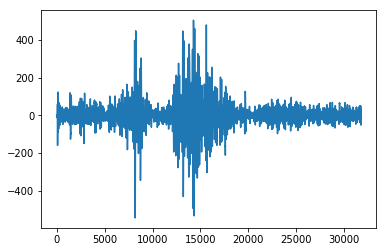

In [22]:
pyplot.plot(data[int(.0 * RATE):])

# Some recordings

In [10]:
!cat VOXFORGE_DATABASE/Dcoetzee-20110429-bne/etc/PROMPTS
!ls recordings/andreas/wav

Dcoetzee-20110429-bne/mfc/b0530 HE HAD A BIG CHIMPANZEE THAT WAS A WINNER
Dcoetzee-20110429-bne/mfc/b0531 I AM SURE IT MUST HAVE BEEN SOME ADVENTURE
Dcoetzee-20110429-bne/mfc/b0532 THAT LONGFELLOW CHAP MOST LIKELY HAD WRITTEN COUNTLESS BOOKS OF POETRY
Dcoetzee-20110429-bne/mfc/b0533 HIS ABNORMAL POWER OF VISION MADE ABSTRACTIONS TAKE ON CONCRETE FORM
Dcoetzee-20110429-bne/mfc/b0534 I'LL TELL YOU THE LIBRARIAN SAID WITH A BRIGHTENING FACE
Dcoetzee-20110429-bne/mfc/b0535 HE READ HIS FRAGMENTS ALOUD
Dcoetzee-20110429-bne/mfc/b0536 TYPHOID DID I TELL YOU
Dcoetzee-20110429-bne/mfc/b0537 BUT SHE HAD BECOME AN AUTOMATON
Dcoetzee-20110429-bne/mfc/b0538 AT THE BEST THEY WERE NECESSARY ACCESSORIES
Dcoetzee-20110429-bne/mfc/b0539 YOU WERE MAKING THEM TALK SHOP RUTH CHARGED HIM
b0530.wav   b0533.wav   b0536.wav   b0539.wav   flowers.wav
b0531.wav   b0534.wav   b0537.wav   blumen.wav  iii.wav
b0532.wav   b0535.wav   b0538.wav   einzwei.wav


In [55]:
data = record(secs=5)[300:] # without initial click
scipy.io.wavfile.write('recordings/andreas/wav/eee.wav', RATE, data)

* recording
* done recording


In [13]:
playback(data)

In [7]:
def plotsound(data, do_emphasize=True):
    if do_emphasize:
        data = emphasize(data, do_plot=False)
    filter_banks = bankize(spectrize(windowed(get_frames(data)), do_plot=False))
    print('filter_banks', filter_banks.shape)

    _, axs = pyplot.subplots(2, 1, figsize=(20, 4), gridspec_kw=dict(height_ratios=(.5, .5)))
    axs[0].plot(np.linspace(0, len(data)/RATE, len(data)), data)
    axs[0].set_xlim((0, len(data)/RATE))
    axs[1].matshow(filter_banks.T, cmap='jet')
    axs[1].set_xticks([])
    pyplot.figure()
    pyplot.plot(filter_banks.mean(axis=0))
    return filter_banks

In [24]:
# for comparison
import os, sys
from audioset import mel_features, vggish_params

import scipy.fftpack

def log_mel_spectrogram(audio_sample_rate, data,
                        do_emphasize=False, cepstrize=False, num_ceps=13,
                        num_mel_bins=vggish_params.NUM_MEL_BINS,
                       ):
    if do_emphasize:
        data = emphasize(data, do_plot=False)
    mel = mel_features.log_mel_spectrogram(
            data=data,
            audio_sample_rate=audio_sample_rate,
            log_offset=vggish_params.LOG_OFFSET,
            window_length_secs=vggish_params.STFT_WINDOW_LENGTH_SECONDS,
            hop_length_secs=vggish_params.STFT_HOP_LENGTH_SECONDS,
            num_mel_bins=num_mel_bins,
            upper_edge_hertz=vggish_params.MEL_MAX_HZ
            )
    print('mel', mel.shape)
    if not cepstrize:
        return mel
    num_ceps = 12
    mfcc = scipy.fftpack.dct(mel, type=2, axis=1, norm='ortho')[:, 1 : (num_ceps + 1)] # Keep 2-13
    print('mfcc', mfcc.shape)
    return mfcc

frames 495 frame_length 400
pow_frames.shape (495, 257)
filter_banks (495, 40)


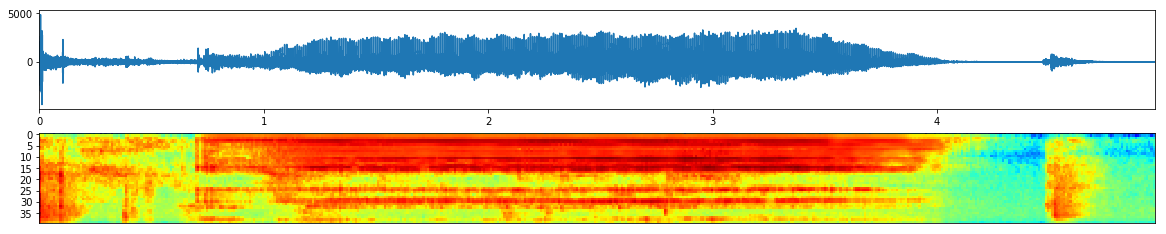

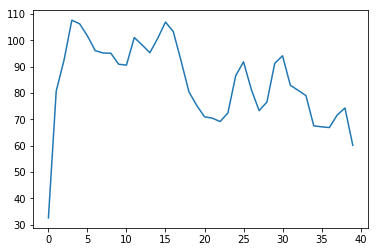

In [8]:
aaa = plotsound(scipy.io.wavfile.read('recordings/andreas/wav/aaa.wav')[1])

mel (495, 40)


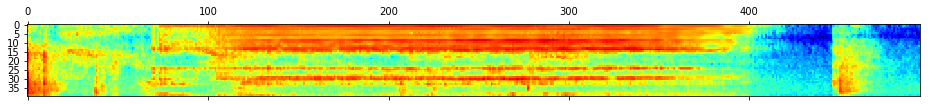

In [19]:
pyplot.figure(figsize=(20, 4))
kw = dict(num_mel_bins=40, do_emphasize=True)
pyplot.matshow(log_mel_spectrogram(*scipy.io.wavfile.read('recordings/andreas/wav/aaa.wav'), **kw).T, cmap='jet');

mel (495, 40)
mfcc (495, 12)


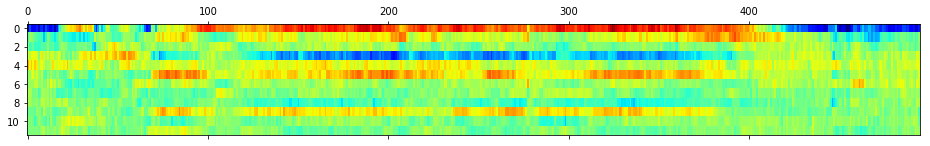

In [26]:
pyplot.figure(figsize=(20, 4))
kw = dict(num_mel_bins=40, do_emphasize=True, cepstrize=True)
mfcc = log_mel_spectrogram(*scipy.io.wavfile.read('recordings/andreas/wav/aaa.wav'), **kw)
pyplot.matshow(mfcc.T, cmap='jet', aspect='auto');

frames 495 frame_length 400
pow_frames.shape (495, 257)


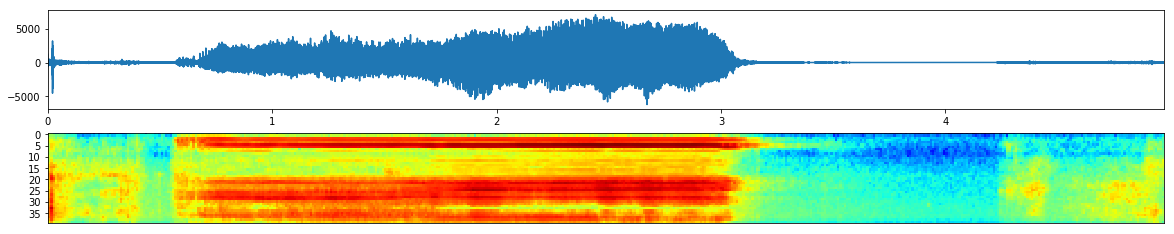

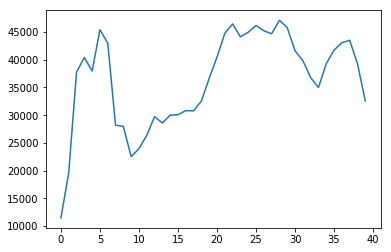

In [71]:
iii = plotsound(scipy.io.wavfile.read('recordings/andreas/wav/iii.wav')[1])

frames 495 frame_length 400
pow_frames.shape (495, 257)


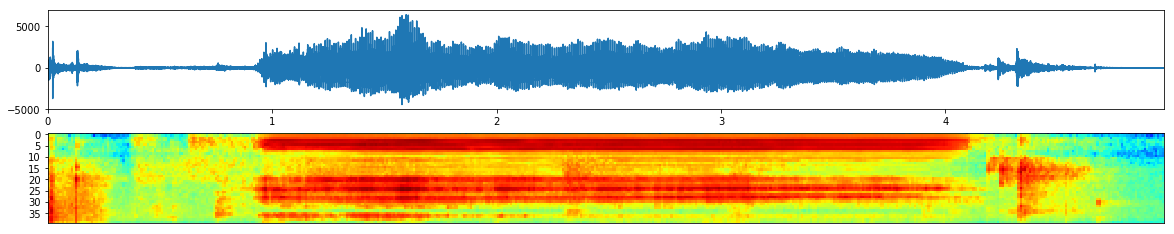

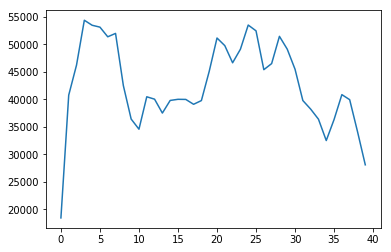

In [72]:
eee = plotsound(scipy.io.wavfile.read('recordings/andreas/wav/eee.wav')[1])

<IPython.core.display.Javascript object>


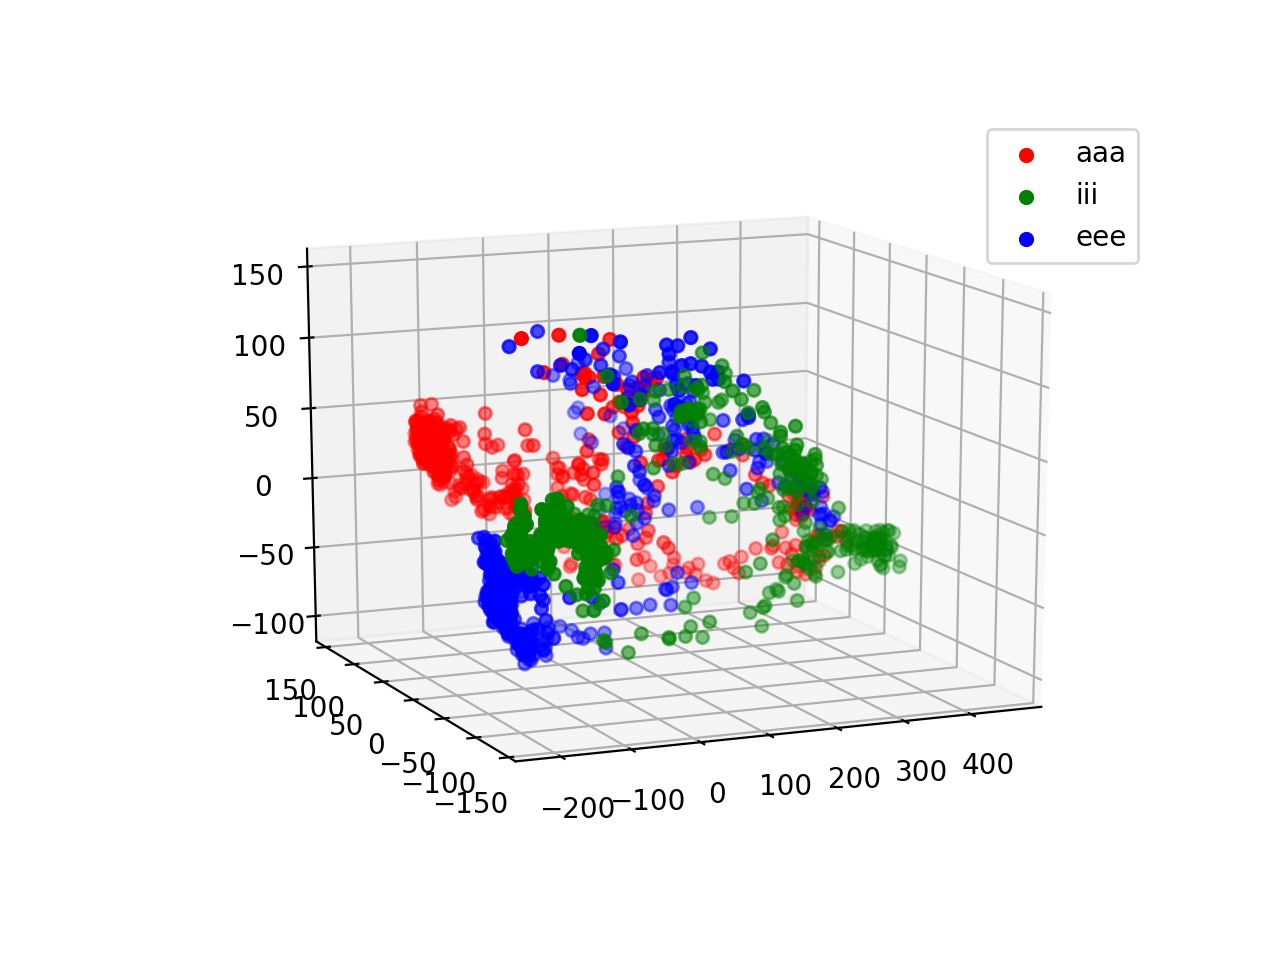

In [89]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(np.vstack([aaa, iii, eee]))
# pca.fit(aaa)

pyplot.scatter(*pca.transform(aaa).T, c='r', label='aaa')
pyplot.scatter(*pca.transform(iii).T, c='g', label='iii')
pyplot.scatter(*pca.transform(eee).T, c='b', label='eee')
pyplot.legend()

%matplotlib notebook
from mpl_toolkits.mplot3d import Axes3D
fig = pyplot.figure()
ax = fig.add_subplot(111, projection='3d')

pca = PCA(n_components=3)
pca.fit(np.vstack([aaa, iii, eee]))
# pca.fit(aaa)

ax.scatter(*pca.transform(aaa).T, c='r', label='aaa')
ax.scatter(*pca.transform(iii).T, c='g', label='iii')
ax.scatter(*pca.transform(eee).T, c='b', label='eee')
ax.legend()


frames 495 frame_length 400
pow_frames.shape (495, 257)
frames 495 frame_length 400
pow_frames.shape (495, 257)


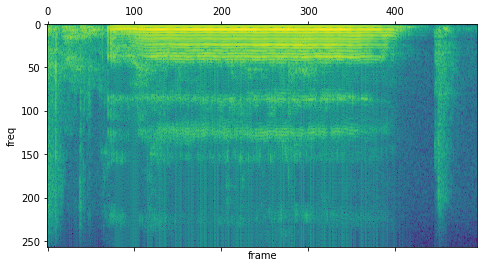

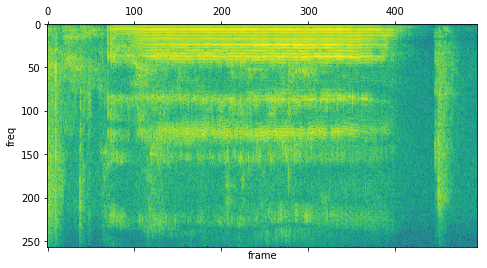

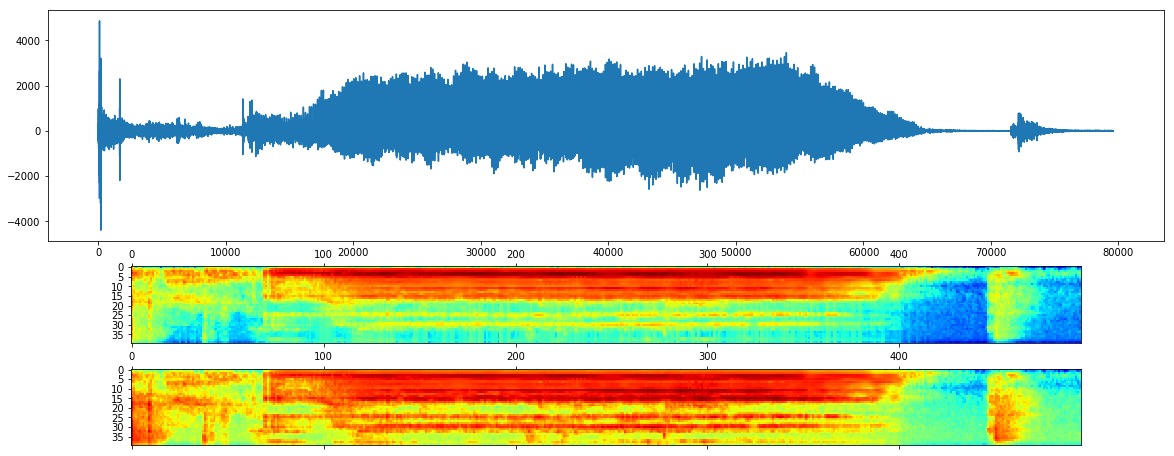

In [14]:
andreas_aaa = scipy.io.wavfile.read('recordings/andreas/wav/aaa.wav')[1]
filter_banks1 = bankize(spectrize(windowed(get_frames(andreas_aaa))))
emphasized_signal = emphasize(andreas_aaa)
filter_banks2 = bankize(spectrize(windowed(get_frames(emphasized_signal))))

_, axs = pyplot.subplots(3, 1, figsize=(20, 8), gridspec_kw=dict(height_ratios=(.6, .2, .2)))
axs[0].plot(emphasized_signal)
axs[1].matshow(filter_banks1.T, cmap='jet')
axs[2].matshow(filter_banks2.T, cmap='jet')

# playback(andreas_aaa)

In [4]:
data = record(secs=3)
print(len(data), RATE)
data = data[800:]  # remove initial click

* recording
* done recording
47104 16000


In [262]:
# all_things_considered = data
# rising = data
# etwas_laenger = data
# doremifa = data
# abcdef = data

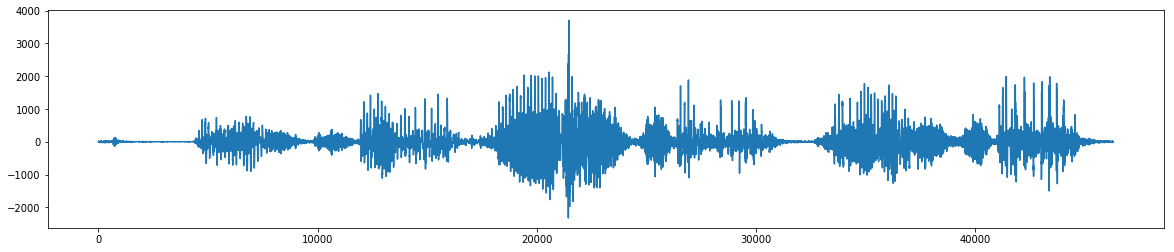

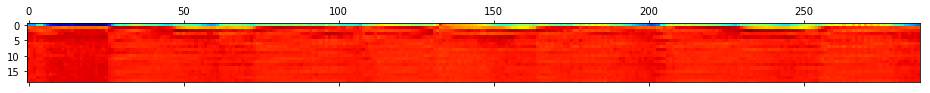

In [6]:
playback(data)

pyplot.figure(figsize=(20, 4))
pyplot.plot(data)

mfcc_ = c(data / 2**15)
mfcc = np.stack(mfcc_).T
pyplot.matshow(mfcc - np.mean(mfcc, axis=0), cmap='jet')

# Filterbanks / MFCC (Haytham Fayek)

http://haythamfayek.com/2016/04/21/speech-processing-for-machine-learning.html (4/2016)

In [250]:
signal = data  # from above
numpy = np

In [5]:
def emphasize(signal, pre_emphasis=.97, do_plot=False, do_playback=False):
    emphasized_signal = np.append(signal[0], signal[1:] - pre_emphasis * signal[:-1]).astype(signal.dtype)
    if do_plot:
        pyplot.plot(np.array(range(len(signal))) / RATE, signal, label='signal')
        pyplot.plot(np.array(range(len(signal))) / RATE, emphasized_signal, label='emphasized')
        pyplot.legend(loc=0)
        pyplot.gca().set_xlabel('secs')
    if do_playback:
        playback(emphasized_signal)
    return emphasized_signal

def get_frames(signal, frame_size_ms=25, frame_stride_ms=10):
    frame_length, frame_step = frame_size_ms / 1e3 * RATE, frame_stride_ms / 1e3 * RATE
    signal_length = len(signal)
    frame_length = int(round(frame_length))
    frame_step = int(round(frame_step))
    num_frames = int(numpy.ceil(float(numpy.abs(signal_length - frame_length)) / frame_step))  # Make sure that we have at least 1 frame

    pad_signal_length = num_frames * frame_step + frame_length
    z = numpy.zeros((pad_signal_length - signal_length))
    pad_signal = numpy.append(signal, z) # Pad Signal to make sure that all frames have equal number of samples without truncating any samples from the original signal

    indices = (numpy.tile(numpy.arange(0, frame_length), (num_frames, 1)) +
               numpy.tile(numpy.arange(0, num_frames * frame_step, frame_step), (frame_length, 1)).T)
    frames = pad_signal[indices.astype(numpy.int32, copy=False)]

    print('frames', len(frames), 'frame_length', frame_length)
    return frames

def windowed(frames, do_plot=False):
    window = np.hamming(len(frames[0]))
    if do_plot:
        pyplot.figure()
        pyplot.plot(window)
        pyplot.gca().set_title('hamming')
    return frames * window

def spectrize(frames, NFFT=512, do_plot=True):
    mag_frames = numpy.absolute(numpy.fft.rfft(frames, NFFT))  # Magnitude of the FFT
    pow_frames = ((1.0 / NFFT) * ((mag_frames) ** 2))  # Power Spectrum
    print('pow_frames.shape', pow_frames.shape)
    if do_plot:
        pyplot.matshow(np.log(pow_frames).T)
        pyplot.gca().set_xlabel('frame')
        pyplot.gca().set_ylabel('freq')
    return pow_frames

def melize(hz):
    return 2595 * numpy.log10(1 + hz / 700)

def unmelize(mel):
    return (700 * (10**(mel / 2595) - 1))

def make_fbank(nfilt, NFFT=512, do_plot=False):
    low_freq_mel = 0
    high_freq_mel = melize(RATE / 2)
    mel_points = numpy.linspace(low_freq_mel, high_freq_mel, nfilt + 2)  # Equally spaced in Mel scale
    hz_points = unmelize(mel_points)
    bin = numpy.floor((NFFT + 1) * hz_points / RATE)

    fbank = numpy.zeros((nfilt, int(numpy.floor(NFFT / 2 + 1))))
    for m in range(1, nfilt + 1):
        f_m_minus = int(bin[m - 1])   # left
        f_m = int(bin[m])             # center
        f_m_plus = int(bin[m + 1])    # right

        for k in range(f_m_minus, f_m):
            fbank[m - 1, k] = (k - bin[m - 1]) / (bin[m] - bin[m - 1])
        for k in range(f_m, f_m_plus):
            fbank[m - 1, k] = (bin[m + 1] - k) / (bin[m + 1] - bin[m])


    if do_plot:
        pyplot.figure(figsize=(20, 4))
        for i in range(fbank.shape[0]):
            pyplot.plot(np.linspace(0, RATE/2, fbank.shape[1]), fbank[i,:])
            
    return fbank

def bankize(pow_frames, nfilt=40):
    fbank = make_fbank(nfilt)
    filter_banks = numpy.dot(pow_frames, fbank.T)
    filter_banks = numpy.where(filter_banks == 0, numpy.finfo(float).eps, filter_banks)  # Numerical Stability
    filter_banks = 20 * numpy.log10(filter_banks)  # dB
    return filter_banks

frames 296 frame_length 1102
pow_frames.shape (296, 257)


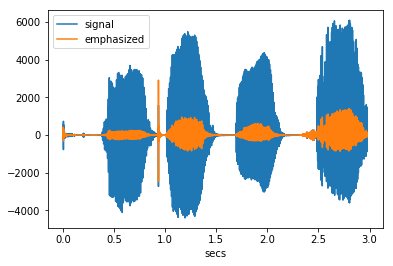

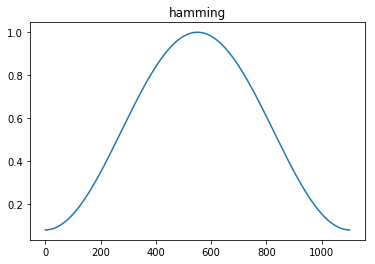

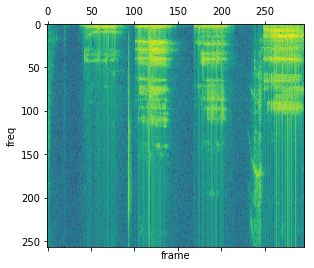

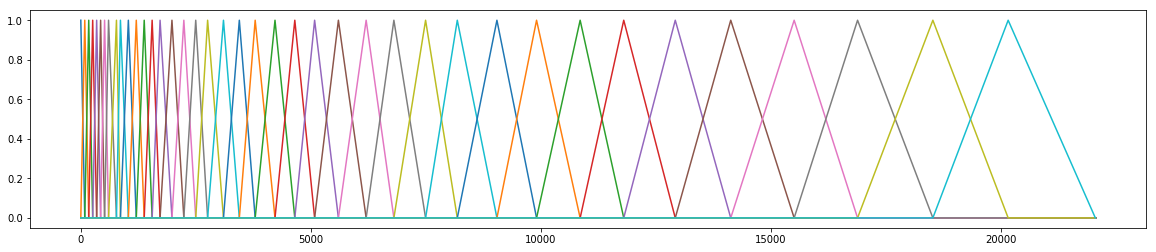

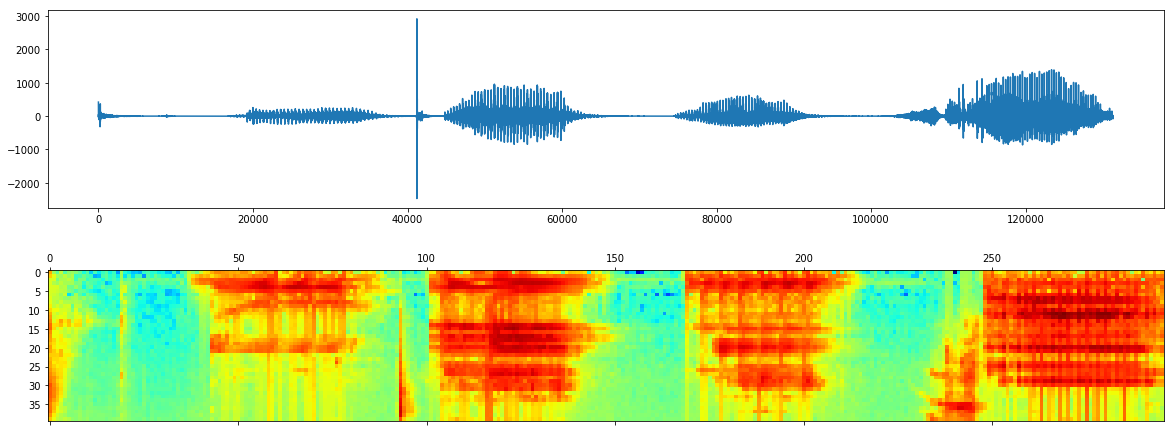

In [280]:
filter_banks = bankize(spectrize(windowed(get_frames(emphasize(signal)))))

_, axs = pyplot.subplots(2, 1, figsize=(20, 8))
axs[0].plot(emphasized_signal)
axs[1].matshow(filter_banks.T, cmap='jet')

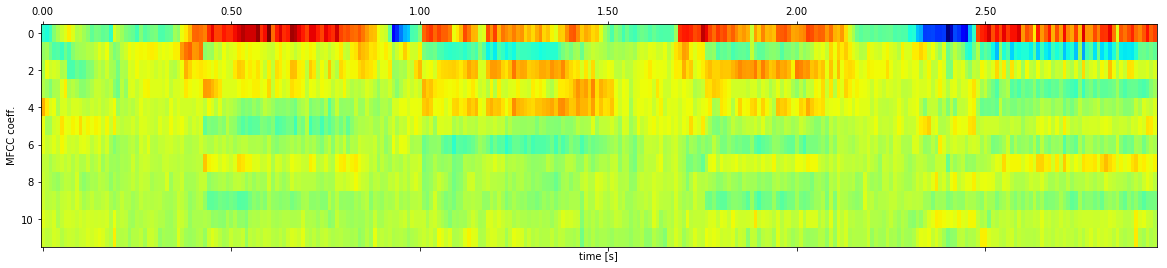

In [329]:
import scipy.fftpack
num_ceps = 12
mfcc = scipy.fftpack.dct(filter_banks, type=2, axis=1, norm='ortho')[:, 1 : (num_ceps + 1)] # Keep 2-13

pyplot.figure(figsize=(20, 4))
pyplot.matshow(mfcc.T, cmap='jet', aspect='auto', fignum=1)
pyplot.gca().set_xlabel('time [s]')
pyplot.gca().set_ylabel('MFCC coeff.')
lim = pyplot.gca().get_xlim()
ticks = pyplot.gca().get_xticks()
pyplot.xticks(ticks, ['%.2f' % (tick * 10e-3) for tick in ticks])
pyplot.gca().set_xlim(lim)
None

In [304]:
playback(signal)